# ApexPlanet 30-Day Data Analytics Internship
## Task 1: Foundational Setup & Exploratory Data Analysis

### Dataset: Online Retail
### Source: UCI Machine Learning Repository

**Objective:**  
Perform data cleaning and exploratory data analysis on an e-commerce
transaction dataset to identify meaningful business insights.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
!pip install openpyxl -q

In [8]:
import pandas as pd

file_path = "/content/Online_Retail.xlsx"

df = pd.read_excel(
    file_path,
    engine="openpyxl"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (541909, 8)


## 4. Initial Dataset Exploration

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [11]:
df.shape

(541909, 8)

In [12]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Checking for missing values

In [14]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [15]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [17]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (536641, 8)


In [18]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [19]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [20]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")

In [22]:
# Remove rows where Description is missing
df = df.dropna(subset=["Description"]).copy()

print("Missing Description values after cleaning:",
      df["Description"].isnull().sum())

print("New dataset shape:", df.shape)

Missing Description values after cleaning: 0
New dataset shape: (535187, 8)


In [23]:
# Final missing-value check
missing_values_after = df.isnull().sum()

missing_percentage_after = (df.isnull().sum() / len(df)) * 100

missing_summary_after = pd.DataFrame({
    "Missing Values": missing_values_after,
    "Percentage": missing_percentage_after
})

missing_summary_after.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
CustomerID,133583,24.960061
InvoiceNo,0,0.000000
Description,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


### Handling Missing CustomerID

The CustomerID column contains missing values. These records were retained
because CustomerID is not required for overall transaction, product,
geographic, and sales trend analysis. Rows with valid CustomerID values
will be used when performing customer-level analysis.

In [24]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

Quantity <= 0: 9725
UnitPrice <= 0: 1058


In [25]:
# Keep only valid sales transactions
df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Shape after removing invalid transactions:", df.shape)

Shape after removing invalid transactions: (524878, 8)


In [26]:
# Calculate total sales amount for each transaction
df["SalesAmount"] = df["Quantity"] * df["UnitPrice"]

df[[
    "Quantity",
    "UnitPrice",
    "SalesAmount"
]].head()

,Quantity,UnitPrice,SalesAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [27]:
# Calculate Q1 and Q3
Q1 = df["SalesAmount"].quantile(0.25)
Q3 = df["SalesAmount"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 3.9
Q3: 17.700000000000003
IQR: 13.800000000000002
Lower Bound: -16.800000000000004
Upper Bound: 38.400000000000006


In [28]:
# Identify outliers
outliers = df[
    (df["SalesAmount"] < lower_bound) |
    (df["SalesAmount"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 42624


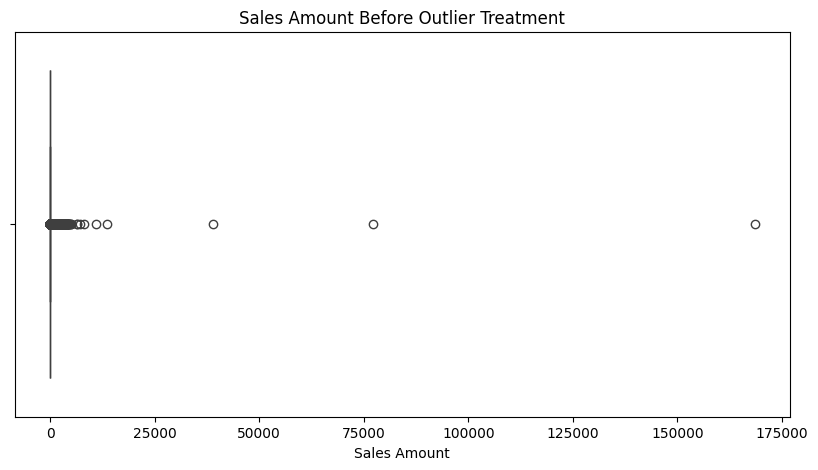

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(x=df["SalesAmount"])

plt.title("Sales Amount Before Outlier Treatment")
plt.xlabel("Sales Amount")

plt.show()

In [30]:
# Remove outliers using IQR method
df = df[
    (df["SalesAmount"] >= lower_bound) &
    (df["SalesAmount"] <= upper_bound)
].copy()

print("Shape after IQR outlier treatment:", df.shape)

Shape after IQR outlier treatment: (482254, 9)


In [31]:
# Check remaining outliers
remaining_outliers = df[
    (df["SalesAmount"] < lower_bound) |
    (df["SalesAmount"] > upper_bound)
]

print("Remaining outliers:", len(remaining_outliers))

Remaining outliers: 0


In [32]:
print("Final Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Final Dataset Shape: (482254, 9)

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     126247
Country             0
SalesAmount         0
dtype: int64

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
SalesAmount           float64
dtype: object


In [33]:
# Save cleaned dataset
cleaned_file = "/content/online_retail_cleaned.csv"

df.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved successfully!")
print("File:", cleaned_file)

Cleaned dataset saved successfully!
File: /content/online_retail_cleaned.csv


In [34]:
print("Final Dataset Shape:", df.shape)
print(df.isnull().sum())
print(df.dtypes)

Final Dataset Shape: (482254, 9)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     126247
Country             0
SalesAmount         0
dtype: int64
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
SalesAmount           float64
dtype: object


# Exploratory Data Analysis (EDA)

The objective of this section is to explore the cleaned Online Retail dataset,
understand its structure and distributions, identify important patterns, and
derive meaningful business insights.

In [35]:
# Dataset dimensions

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 482254
Number of Columns: 9


In [36]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,482254.0,6.26383,1.0,1.0,3.0,9.0,900.0,8.944853
InvoiceDate,482254,2011-07-04 20:57:25.856830208,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-20 12:01:00,2011-10-19 13:58:00,2011-12-09 12:50:00,NaN
UnitPrice,482254.0,3.14032,0.001,1.25,2.08,4.13,38.26,3.260993
CustomerID,356007.0,15319.083423,12347.0,13993.0,15218.0,16814.0,18287.0,1708.496247
SalesAmount,482254.0,10.541462,0.001,3.4,8.4,15.9,38.4,8.318965


In [37]:
# Number of unique values in each column

unique_values = df.nunique().sort_values(ascending=False)

unique_values

,0
InvoiceNo,18088
InvoiceDate,16864
CustomerID,4185
Description,3988
StockCode,3894
SalesAmount,1398
UnitPrice,394
Quantity,98
Country,38


# Distribution of Quantities

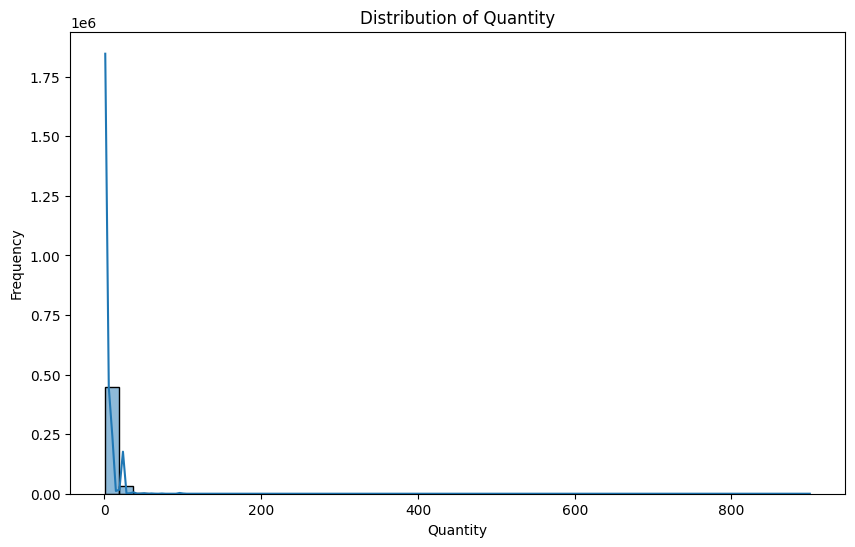

In [38]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Quantity"],
    bins=50,
    kde=True
)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

# Distribution of Retail Price

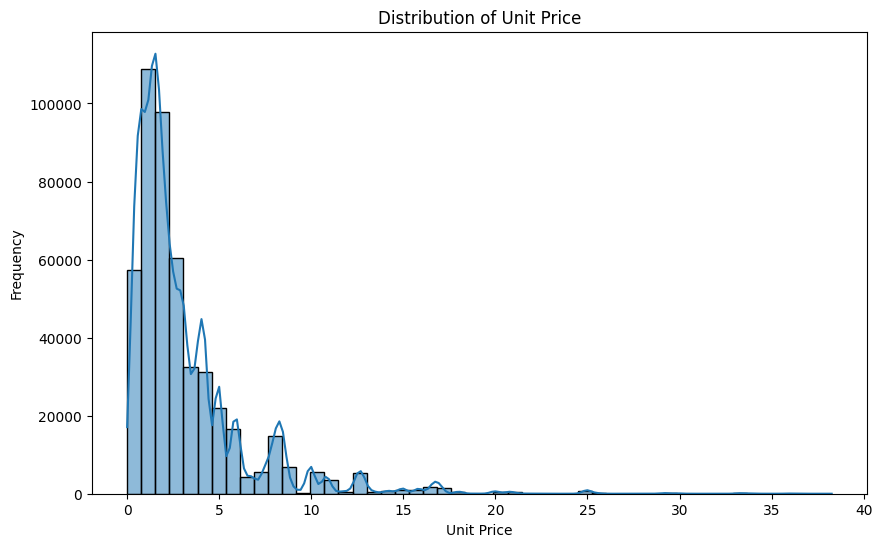

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["UnitPrice"],
    bins=50,
    kde=True
)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

# Distribution of Sales Amount

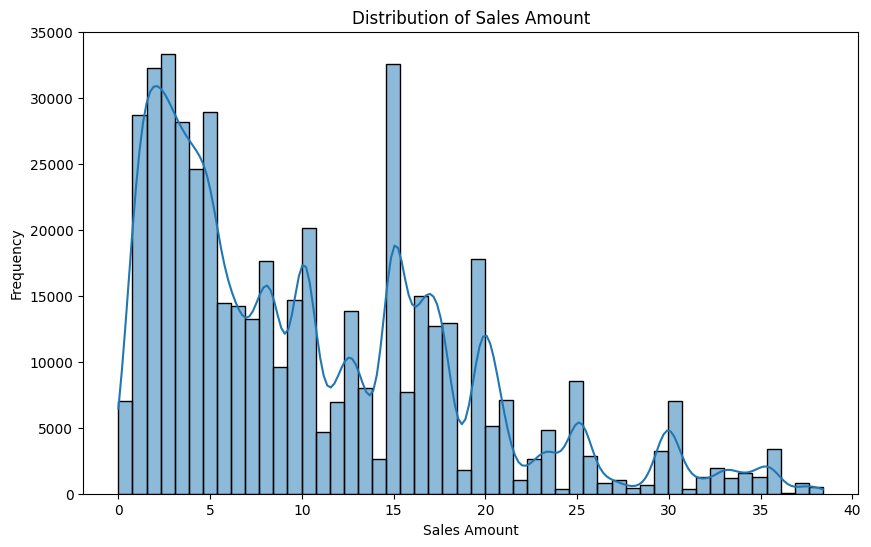

In [40]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["SalesAmount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")

plt.show()

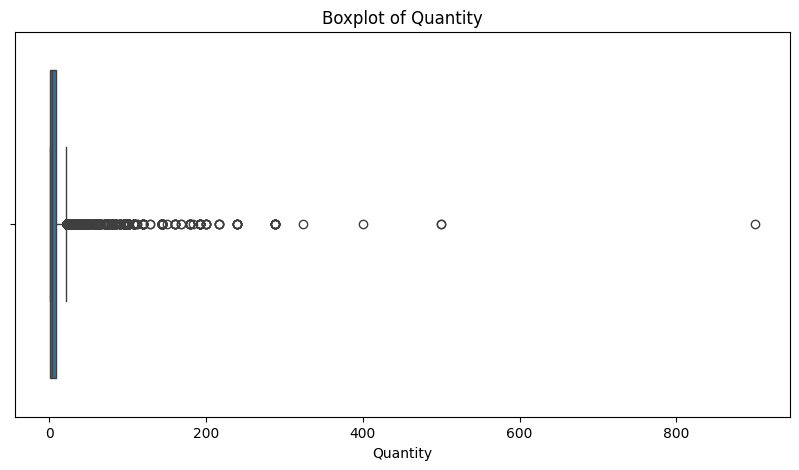

In [41]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Quantity")
plt.xlabel("Quantity")

plt.show()

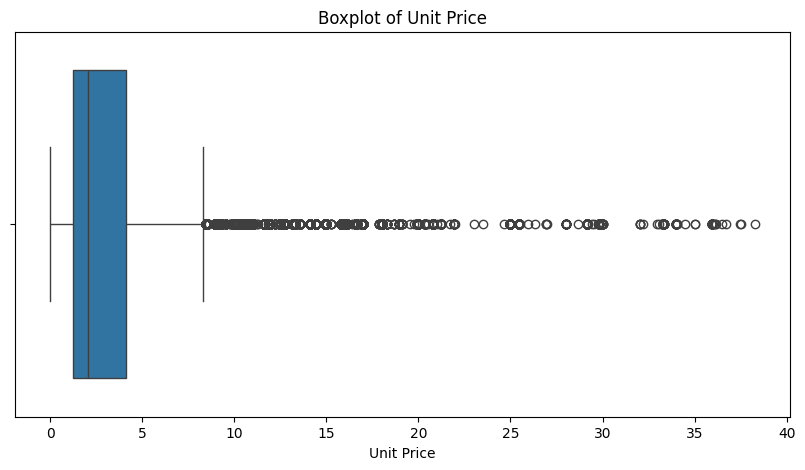

In [42]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["UnitPrice"])

plt.title("Boxplot of Unit Price")
plt.xlabel("Unit Price")

plt.show()

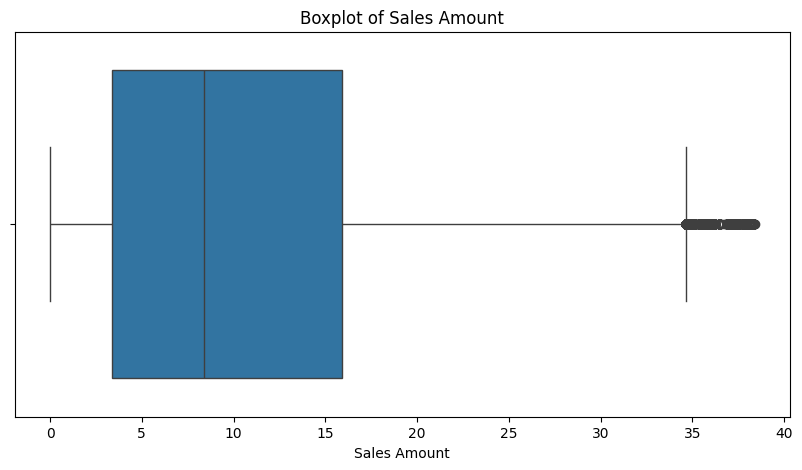

In [43]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["SalesAmount"])

plt.title("Boxplot of Sales Amount")
plt.xlabel("Sales Amount")

plt.show()

# Top 10 Products by Sales

In [44]:
top_products = (
    df.groupby("Description")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,SalesAmount
Description,
WHITE HANGING HEART T-LIGHT HOLDER,30041.67
REGENCY CAKESTAND 3 TIER,25682.37
JUMBO BAG RED RETROSPOT,22518.76
ASSORTED COLOUR BIRD ORNAMENT,18708.19
SET OF 3 CAKE TINS PANTRY DESIGN,18602.41
PARTY BUNTING,18536.02
NATURAL SLATE HEART CHALKBOARD,18452.16
LUNCH BAG RED RETROSPOT,17863.63
JAM MAKING SET WITH JARS,16534.22


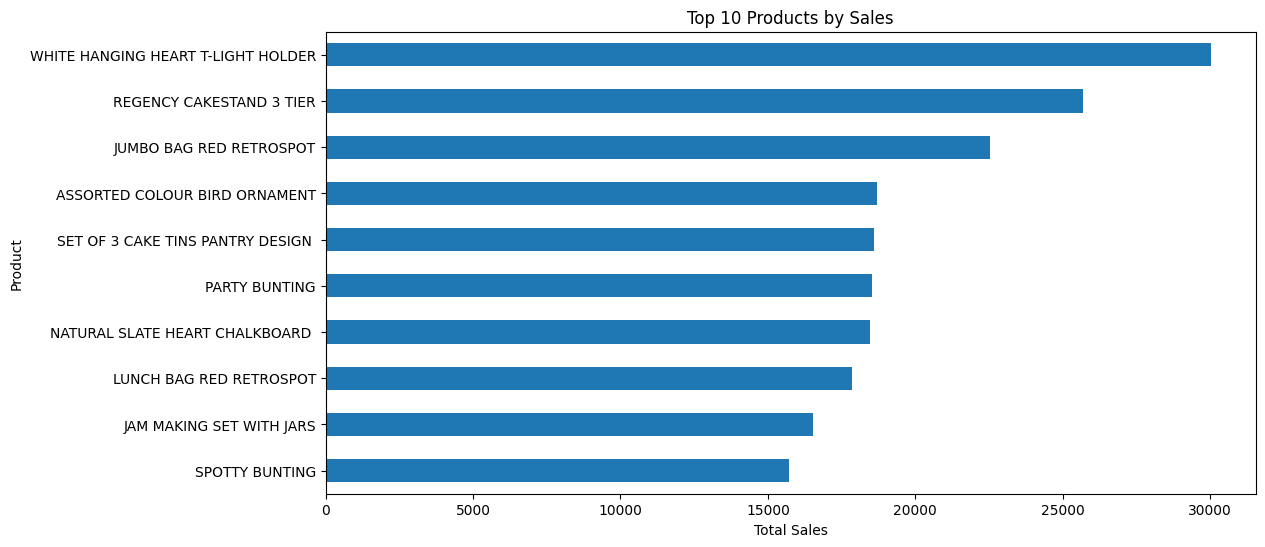

In [45]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

# Top 10 countries by Sales

In [46]:
country_sales = (
    df.groupby("Country")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

,SalesAmount
Country,
United Kingdom,4482481.404
Germany,132087.150
France,120276.600
EIRE,111588.990
Spain,32103.310
Belgium,31360.040
Switzerland,26863.300
Portugal,19580.680
Norway,14560.410


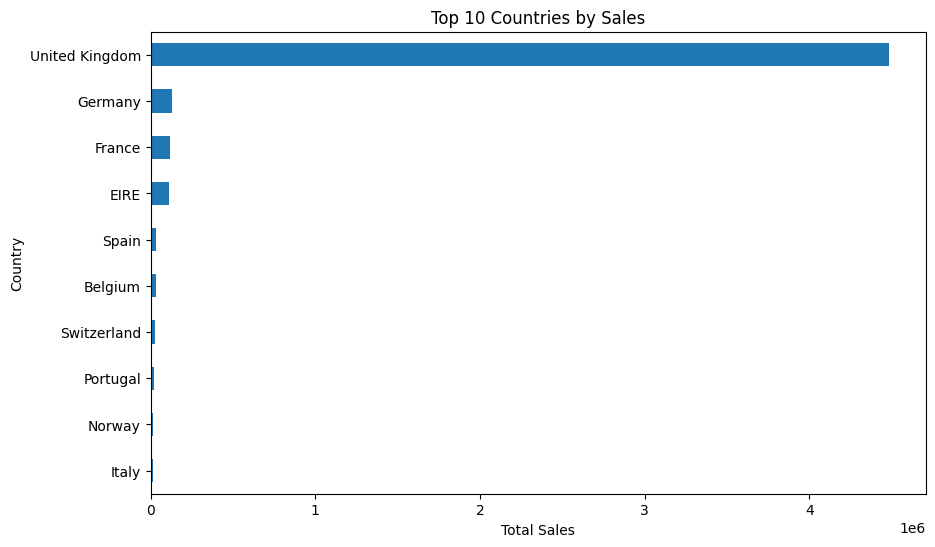

In [47]:
plt.figure(figsize=(10, 6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.show()

# Number of Orders by Country

In [48]:
orders_by_country = (
    df.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

orders_by_country

,InvoiceNo
Country,
United Kingdom,16332
Germany,437
France,375
EIRE,257
Belgium,98
Spain,82
Netherlands,65
Portugal,49
Switzerland,47


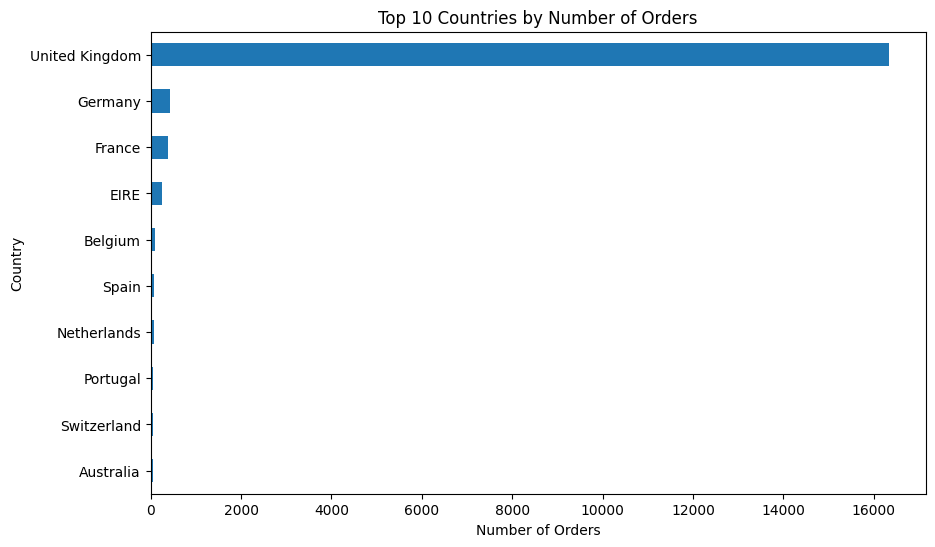

In [49]:
plt.figure(figsize=(10, 6))

orders_by_country.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Country")

plt.show()

# Monthly Sales Trend

In [50]:
# Create Year-Month column

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("YearMonth")["SalesAmount"]
    .sum()
)

monthly_sales

,SalesAmount
YearMonth,
2010-12,382882.640
2011-01,311149.480
2011-02,267715.360
2011-03,348730.100
2011-04,288216.921
2011-05,376194.110
2011-06,347813.370
2011-07,352784.951
2011-08,351002.740


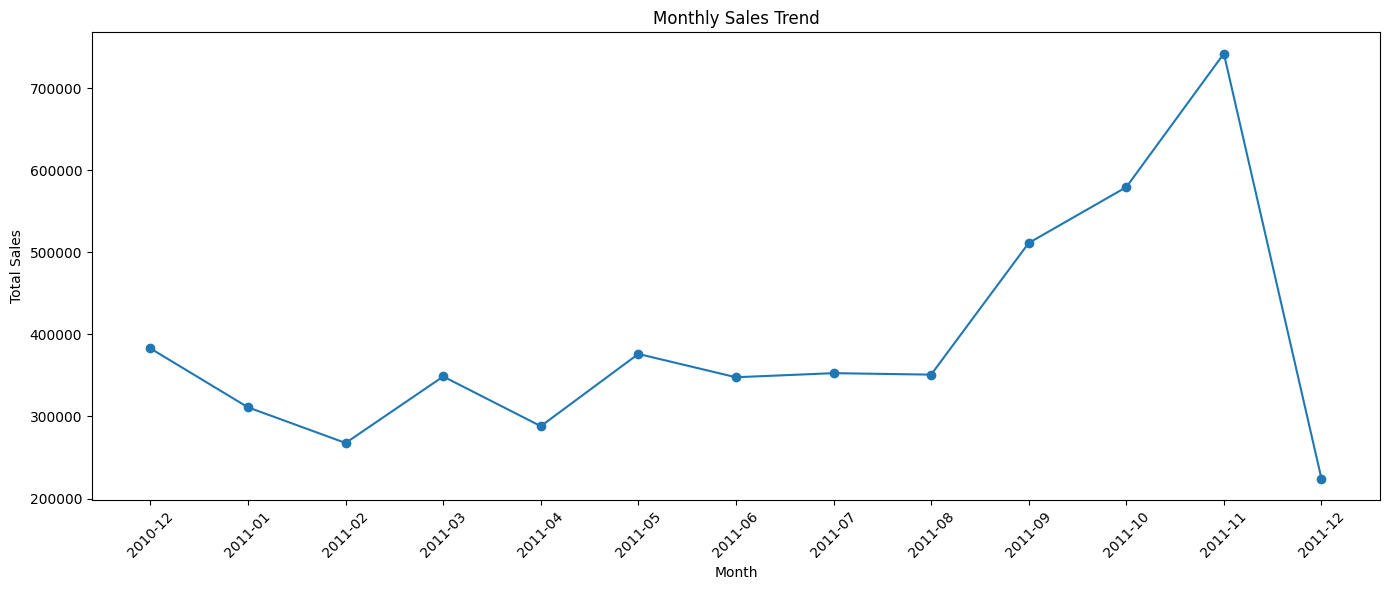

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Monthly number of Orders

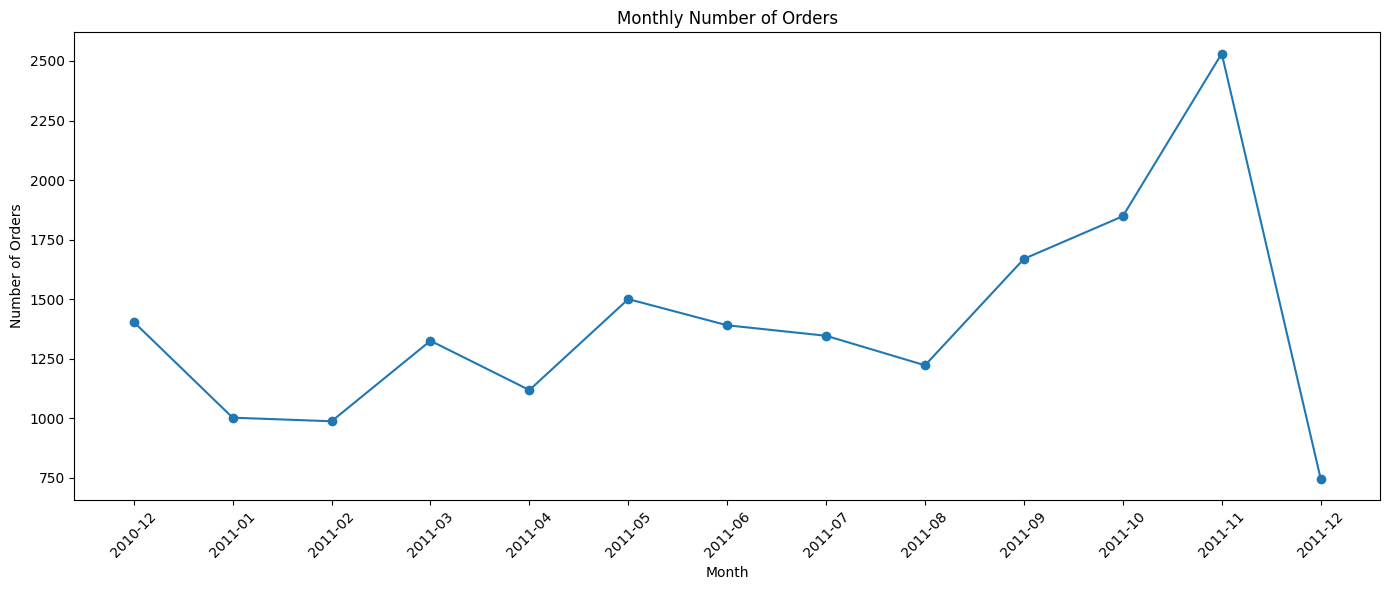

In [52]:
monthly_orders = (
    df.groupby("YearMonth")["InvoiceNo"]
    .nunique()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Correlation HeatMap

In [53]:
# Select numerical columns

numeric_columns = [
    "Quantity",
    "UnitPrice",
    "SalesAmount"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Quantity,UnitPrice,SalesAmount
Quantity,1.000000,-0.312968,0.395527
UnitPrice,-0.312968,1.000000,0.307103
SalesAmount,0.395527,0.307103,1.000000


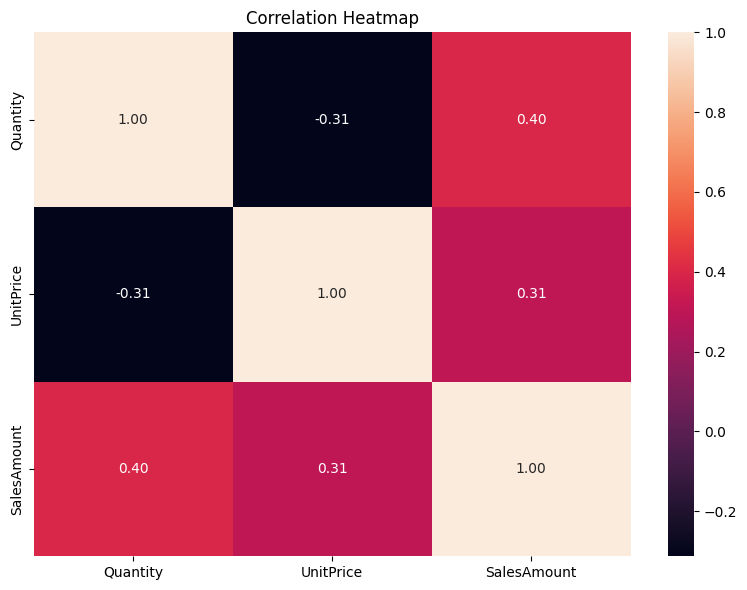

In [54]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# Top Customers by Sales

In [55]:
customer_df = df.dropna(subset=["CustomerID"]).copy()

customer_sales = (
    customer_df
    .groupby("CustomerID")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_sales

,SalesAmount
CustomerID,
14911.0,85414.00
14096.0,41309.87
17841.0,35231.15
13089.0,26948.74
14298.0,25738.29
12748.0,23134.23
13081.0,15083.56
14156.0,13137.98
15311.0,13123.14


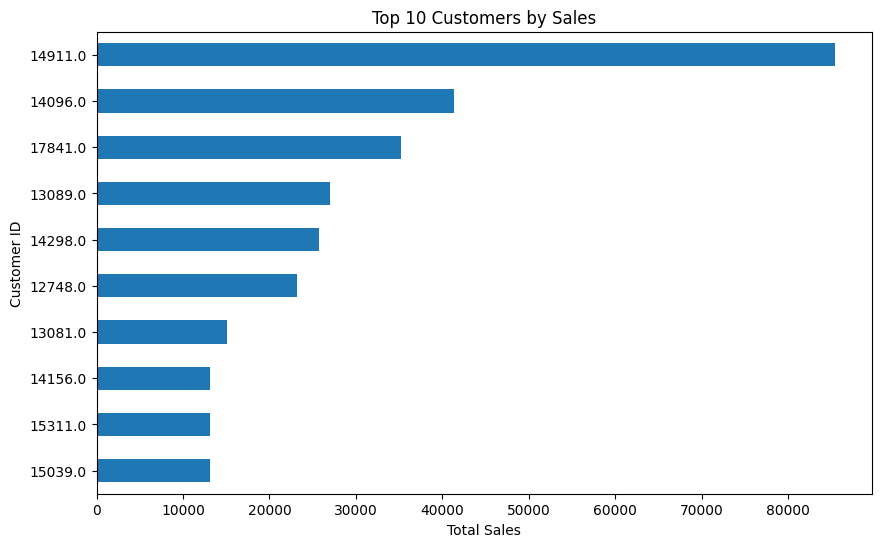

In [56]:
plt.figure(figsize=(10, 6))

customer_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")

plt.show()

# Counrty Wise Average Order Value

In [57]:
country_aov = (
    df.groupby("Country")["SalesAmount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

country_aov

,SalesAmount
Country,
Czech Republic,22.653333
Lithuania,21.190909
Bahrain,21.076923
Lebanon,20.826071
United Arab Emirates,20.104746
Singapore,19.016964
Hong Kong,18.976667
Brazil,18.924545
European Community,18.745370


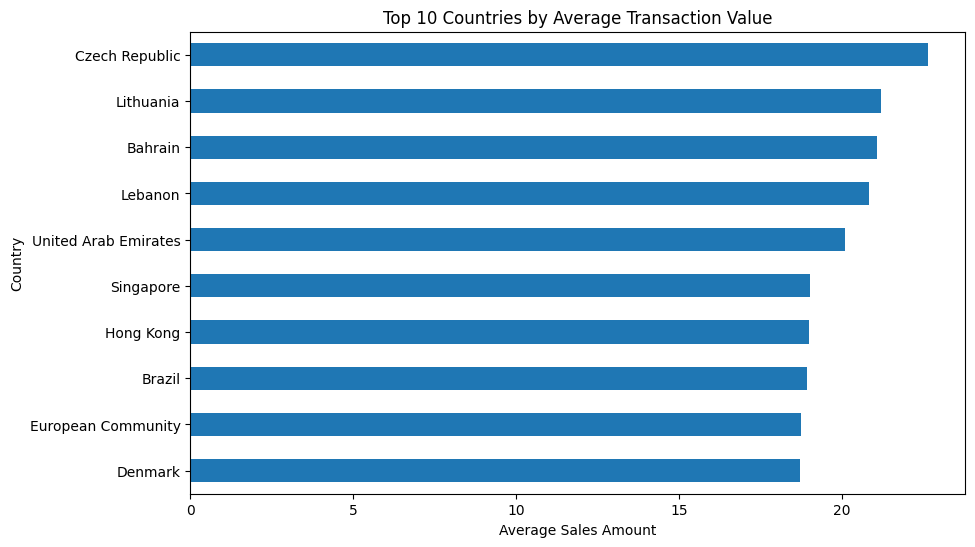

In [58]:
plt.figure(figsize=(10, 6))

country_aov.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Average Transaction Value")
plt.xlabel("Average Sales Amount")
plt.ylabel("Country")

plt.show()

# EDA Summary

# Key Findings

The exploratory analysis was performed to understand transaction volume,
sales performance, product performance, geographic distribution, and
sales trends over time.

The major insights identified from the analysis are documented below.

## **5 Key Findings**

1. The United Kingdom dominates order volume, with substantially more orders than any other country in the dataset.

2. White Hanging Heart T-Light Holder is the highest-selling product among the top 10 products, generating approximately £30,000 in sales.

3. November 2011 recorded the highest number of orders, exceeding 2,500 orders, while December 2011 showed a sharp decline in the available data.

4. The top customer generated approximately £85,000 in total sales, considerably higher than the other top customers, indicating a concentration of sales among certain customers.

5. Quantity has the strongest positive correlation with SalesAmount (0.40), followed by UnitPrice (0.31). Quantity and UnitPrice have a moderate negative correlation of -0.31.